# Prerequisites & Environment Setup

- `torch`: **2.5.0**
- `torchvision`: **0.20.0**



In [2]:
  !pip install torch==2.5.0 torchvision==0.20.0 matplotlib tensorboard  

# Lab 0 — Task 2: Transfer Learning with AlexNet on CIFAR-10

## What is Transfer Learning?

When training a deep neural network from scratch, you need:
- A **huge amount of labeled data** (millions of images)
- **A lot of compute** (days/weeks of GPU time)

Most real-world problems don't have either. **Transfer Learning** is the idea that a model trained on one large task (e.g., classifying 1000 categories of images from ImageNet) has already learned **general visual features** — edges, textures, shapes, object parts — that are useful for *other* image tasks.

Instead of starting from random weights, you:
1. Take a model that was already trained on a big dataset (called a **pretrained model**)
2. Adapt it to your smaller, specific task

This is like hiring an expert photographer to learn portrait photography — they already know composition, lighting, and lenses. They only need to learn the specifics of portraits, not photography from scratch.

---

## What is AlexNet?

AlexNet (Krizhevsky et al., 2012) was the model that **ignited the deep learning revolution**. It won the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) in 2012 by a huge margin, achieving ~15% top-5 error vs ~26% for the next best method.

Its architecture:
```
Input (224×224×3)
  → Conv1 (96 filters, 11×11, stride 4) + ReLU + MaxPool
  → Conv2 (256 filters, 5×5) + ReLU + MaxPool
  → Conv3 (384 filters, 3×3) + ReLU
  → Conv4 (384 filters, 3×3) + ReLU
  → Conv5 (256 filters, 3×3) + ReLU + MaxPool
  → Flatten
  → FC6 (4096) + ReLU + Dropout
  → FC7 (4096) + ReLU + Dropout
  → FC8 (1000) ← original output: 1000 ImageNet classes
```

**Key innovations at the time:** ReLU activations, Dropout regularization, data augmentation, GPU training.

---

## What is CIFAR-10?

CIFAR-10 is a dataset of **60,000 color images** (32×32 pixels) across **10 classes**:  
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

- 50,000 training images
- 10,000 test images

⚠️ **Important mismatch:** AlexNet was designed for **224×224** input images. CIFAR-10 images are only **32×32**. We must resize them before feeding into AlexNet.

---

## The Two Experiments

| | Experiment 1: Fine-Tuning | Experiment 2: Feature Extraction |
|---|---|---|
| **Pretrained weights?** | ❌ No (random init) | ✅ Yes (ImageNet) |
| **Which layers train?** | All layers | Only the final FC layer |
| **Also called** | Training from scratch | Freezing the backbone |

In **Experiment 1**, we use AlexNet's *architecture* but start with random weights. All layers will learn from CIFAR-10 data.

In **Experiment 2**, we use AlexNet's *pretrained weights* (learned from 1.2M ImageNet images). We freeze the convolutional backbone — it already knows how to extract visual features. We only train the final classifier layer to map those features to CIFAR-10's 10 classes.

## Step 1: Imports and Device Setup

We use PyTorch and torchvision. The device setup is important:
- **`mps`** — Apple Silicon GPU (M1/M2/M3). Much faster than CPU on Mac.
- **`cuda`** — NVIDIA GPU
- **`cpu`** — fallback

The model and all data tensors must live on the **same device**.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.tensorboard import SummaryWriter

# Device selection: prefer MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

Using device: mps


## Step 2: Data Preparation

### Why do we resize to 224×224?

AlexNet's first convolutional layer uses an **11×11 kernel with stride 4**, designed for 224×224 inputs. If we feed 32×32 images directly, the feature maps collapse to nearly nothing after the pooling layers, and the fully connected layers receive garbage input.

So we **upscale** CIFAR-10's 32×32 images to 224×224. This is not ideal (upscaling doesn't add real information) but it makes AlexNet's architecture work correctly.

### Why normalize with ImageNet statistics?

The pretrained AlexNet weights were trained on ImageNet data that was normalized with:
- **Mean**: `[0.485, 0.456, 0.406]` (per channel: R, G, B)
- **Std**: `[0.229, 0.224, 0.225]`

For Experiment 2 (pretrained), using the same normalization ensures the input distribution matches what the pretrained model expects. For consistency, we use the same normalization in Experiment 1 too.

### What does normalization do?

It shifts and scales the pixel values so they have approximately zero mean and unit variance. This helps gradient-based optimization converge faster and more stably.

In [7]:
# ImageNet normalization statistics
# These are the mean and std of ImageNet pixel values per channel (R, G, B)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),       # Upscale 32×32 → 224×224 for AlexNet
    transforms.ToTensor(),               # Convert PIL image to tensor [0, 1]
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)  # Normalize
])

# Download and load CIFAR-10
# train=True  → 50,000 training images
# train=False → 10,000 test images
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

# DataLoader batches the data and shuffles training data each epoch
# batch_size=64: process 64 images at a time
# num_workers=2: use 2 background threads to load data (speeds things up)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=2)

# CIFAR-10 class names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print(f'Training samples : {len(trainset)}')
print(f'Test samples     : {len(testset)}')
print(f'Classes          : {classes}')

Files already downloaded and verified
Files already downloaded and verified
Training samples : 50000
Test samples     : 10000
Classes          : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Step 3: Understanding the AlexNet Architecture

PyTorch's `torchvision.models.alexnet()` gives us the full AlexNet. Let's inspect it before modifying it.

AlexNet in PyTorch is organized into two parts:
- **`model.features`** — the convolutional backbone (5 conv layers + pooling)
- **`model.classifier`** — the fully connected head (3 FC layers)

The final layer `classifier[6]` outputs **1000 values** (one per ImageNet class). We need to replace it with a layer that outputs **10 values** (one per CIFAR-10 class).

In [9]:
# Load AlexNet without pretrained weights just to inspect the architecture
temp_model = models.alexnet(weights=None)
print('=== AlexNet Architecture ===')
print(temp_model)
print()
print('=== Classifier head (the FC layers) ===')
print(temp_model.classifier)
print()
print(f'Final layer output size: {temp_model.classifier[6].out_features} (ImageNet classes)')
print(f'We will replace this with a layer outputting 10 (CIFAR-10 classes)')

=== AlexNet Architecture ===
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, ou

## Step 4: Model Builder Helper

We define a helper function that handles both experiments:

### `use_pretrained=False` (Experiment 1 — Fine-Tuning)
- All weights are **randomly initialized**
- All layers will be **trained** on CIFAR-10
- The model must learn everything from the ~50k CIFAR-10 images

### `use_pretrained=True` (Experiment 2 — Feature Extraction)
- Weights are loaded from **ImageNet training** (learned from 1.2M images)
- The convolutional backbone is **frozen** (`requires_grad = False`)
  - Frozen means: no gradients computed → no weight updates during backprop
  - These layers act as a fixed **feature extractor**
- Only the new final FC layer is trainable

### Why modify only `classifier[6]`?
The original last layer has shape `(4096 → 1000)`. We replace it with `(4096 → 10)`. The input size (4096) stays the same — we're just changing the output to match our 10 classes.

In [11]:
def build_alexnet(use_pretrained: bool) -> nn.Module:
    """
    Build AlexNet adapted for CIFAR-10 (10 output classes).
    
    Args:
        use_pretrained: If True, load ImageNet weights and freeze the backbone.
                        If False, use random weights and train everything.
    
    Returns:
        AlexNet model moved to the global `device`.
    """
    if use_pretrained:
        # Load weights pretrained on ImageNet
        model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        
        # FREEZE the convolutional backbone
        # requires_grad=False tells PyTorch: don't compute gradients for these params
        # → these layers won't be updated during training (they're fixed feature extractors)
        for param in model.features.parameters():
            param.requires_grad = False
        
        print('Loaded pretrained ImageNet weights.')
        print('Convolutional backbone: FROZEN (will not be updated)')
    else:
        # Random initialization — no pretrained weights
        model = models.alexnet(weights=None)
        print('No pretrained weights — all parameters randomly initialized.')
        print('All layers: TRAINABLE')
    
    # Replace the final classifier layer:
    # Original: Linear(4096, 1000)  ← 1000 ImageNet classes
    # New:      Linear(4096, 10)    ← 10 CIFAR-10 classes
    # This new layer is always trainable (requires_grad=True by default)
    in_features = model.classifier[6].in_features  # 4096
    model.classifier[6] = nn.Linear(in_features, 10)
    
    print(f'Replaced classifier[6]: Linear({in_features}, 1000) → Linear({in_features}, 10)')
    
    # Count trainable vs frozen parameters
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total parameters     : {total_params:,}')
    print(f'Trainable parameters : {trainable_params:,}')
    print(f'Frozen parameters    : {total_params - trainable_params:,}')
    
    return model.to(device)

## Step 5: Training and Evaluation Helpers

### Training Loop

Each **epoch** is one full pass through the training data. Within each epoch:
1. **Forward pass** — feed input through the model, get predictions
2. **Compute loss** — measure how wrong the predictions are (CrossEntropyLoss)
3. **Backward pass** — compute gradients via backpropagation
4. **Update weights** — optimizer adjusts weights in the direction that reduces loss

### CrossEntropyLoss
The standard loss for multi-class classification. It combines `Softmax + NegativeLogLikelihood`. Intuitively: it penalizes the model heavily when it's confidently wrong.

### SGD Optimizer
Stochastic Gradient Descent with momentum. `lr=0.001` is a safe learning rate for AlexNet with pretrained weights (too high would destroy the pretrained features).

### Evaluation
`model.eval()` switches off Dropout (which randomly disables neurons during training for regularization). During evaluation we want deterministic, full-capacity predictions. We also use `torch.no_grad()` to skip gradient computation — we don't need it for evaluation, and skipping it saves memory and speeds things up.

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, epoch, writer, tag):
    """Train for one epoch. Returns average loss."""
    model.train()
    running_loss = 0.0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(loader)
    writer.add_scalar(f"Loss/train/{tag}", avg_loss, epoch)
    return avg_loss


def evaluate(model, loader, criterion, epoch, writer, tag):
    """Evaluate on test set. Returns (accuracy %, avg loss)."""
    model.eval()
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100.0 * correct / total
    avg_loss = running_loss / len(loader)
    writer.add_scalar(f"Accuracy/test/{tag}", accuracy, epoch)
    writer.add_scalar(f"Loss/test/{tag}", avg_loss, epoch)
    return accuracy, avg_loss


def run_experiment(model, num_epochs, writer, tag):
    """Full training + evaluation loop. Returns (final_accuracy, history_dict)."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.001, momentum=0.9
    )
    history = {"train_loss": [], "test_loss": [], "test_acc": []}
    print("=" * 50)
    print(f"Starting: {tag}")
    print("=" * 50)
    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, trainloader, criterion, optimizer, epoch, writer, tag)
        test_acc, test_loss = evaluate(model, testloader, criterion, epoch, writer, tag)
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        print(f"Epoch [{epoch+1:2d}/{num_epochs}]  "
              f"Train Loss: {train_loss:.4f}  |  "
              f"Test Loss: {test_loss:.4f}  |  "
              f"Test Accuracy: {test_acc:.2f}%")
    print(f"Final Test Accuracy ({tag}): {test_acc:.2f}%")
    return test_acc, history


---
## Experiment 1: Fine-Tuning (No Pretrained Weights)

In this experiment:
- AlexNet's architecture is used, but all weights start **randomly initialized**
- **All layers** are trained on CIFAR-10 from scratch
- This is the baseline — how well can AlexNet learn CIFAR-10 with only a few epochs?

**What to expect:** With only 5 epochs and 50k training images (small for AlexNet), the model will start learning but may not converge to high accuracy. AlexNet was designed for much larger datasets.

In [15]:
NUM_EPOCHS = 5

writer_exp1 = SummaryWriter(log_dir="runs/lab0_task2_exp1_finetuning")

print("Building model for Experiment 1 (Fine-Tuning)...")
print("-" * 50)
model_exp1 = build_alexnet(use_pretrained=False)

acc_exp1, history_exp1 = run_experiment(model_exp1, NUM_EPOCHS, writer_exp1, tag="Exp1_FineTuning")

writer_exp1.close()

Building model for Experiment 1 (Fine-Tuning)...
--------------------------------------------------
No pretrained weights — all parameters randomly initialized.
All layers: TRAINABLE
Replaced classifier[6]: Linear(4096, 1000) → Linear(4096, 10)
Total parameters     : 57,044,810
Trainable parameters : 57,044,810
Frozen parameters    : 0
Starting: Exp1_FineTuning
Epoch [ 1/5]  Train Loss: 2.3003  |  Test Loss: 2.2891  |  Test Accuracy: 12.41%
Epoch [ 2/5]  Train Loss: 2.0314  |  Test Loss: 1.8354  |  Test Accuracy: 33.49%
Epoch [ 3/5]  Train Loss: 1.6552  |  Test Loss: 1.5217  |  Test Accuracy: 43.86%
Epoch [ 4/5]  Train Loss: 1.4810  |  Test Loss: 1.4165  |  Test Accuracy: 48.27%
Epoch [ 5/5]  Train Loss: 1.3590  |  Test Loss: 1.2741  |  Test Accuracy: 53.89%
Final Test Accuracy (Exp1_FineTuning): 53.89%


---
## Experiment 2: Feature Extraction (Pretrained ImageNet Weights)

In this experiment:
- AlexNet's weights are loaded from **ImageNet pretraining** (trained on 1.2M images, 1000 classes)
- The **convolutional backbone is frozen** — these layers already know how to detect edges, textures, and shapes
- Only the **final classifier layer** (which we replaced with a 10-class version) is trained

### Why might this work better?

The convolutional layers in AlexNet have learned **hierarchical visual features**:
- Early layers → edges, colors, gradients
- Middle layers → textures, patterns
- Later layers → object parts (wheels, eyes, fur)

These features are general enough to be useful for CIFAR-10 too. The final FC layer just needs to learn **which combination of these features** corresponds to each CIFAR-10 class.

### Why is training faster?

With the backbone frozen, only the last layer's weights (~40,960 parameters) are updated each step, instead of all 57M+ parameters. This means each training step is much faster and we need fewer examples to get good results.

**What to expect:** Higher accuracy than Experiment 1, even in the same number of epochs, because we're starting from strong pretrained features rather than random noise.

In [17]:
writer_exp2 = SummaryWriter(log_dir="runs/lab0_task2_exp2_feature_extraction")

print("Building model for Experiment 2 (Feature Extraction)...")
print("-" * 50)
model_exp2 = build_alexnet(use_pretrained=True)

acc_exp2, history_exp2 = run_experiment(model_exp2, NUM_EPOCHS, writer_exp2, tag="Exp2_FeatureExtraction")

writer_exp2.close()

Building model for Experiment 2 (Feature Extraction)...
--------------------------------------------------
Loaded pretrained ImageNet weights.
Convolutional backbone: FROZEN (will not be updated)
Replaced classifier[6]: Linear(4096, 1000) → Linear(4096, 10)
Total parameters     : 57,044,810
Trainable parameters : 54,575,114
Frozen parameters    : 2,469,696
Starting: Exp2_FeatureExtraction
Epoch [ 1/5]  Train Loss: 0.7136  |  Test Loss: 0.5087  |  Test Accuracy: 82.22%
Epoch [ 2/5]  Train Loss: 0.5463  |  Test Loss: 0.4607  |  Test Accuracy: 84.26%
Epoch [ 3/5]  Train Loss: 0.4905  |  Test Loss: 0.4314  |  Test Accuracy: 84.79%
Epoch [ 4/5]  Train Loss: 0.4500  |  Test Loss: 0.4127  |  Test Accuracy: 85.97%
Epoch [ 5/5]  Train Loss: 0.4171  |  Test Loss: 0.4038  |  Test Accuracy: 85.95%
Final Test Accuracy (Exp2_FeatureExtraction): 85.95%


---
## Results Comparison

Let's compare the final test accuracies of both experiments.

In [19]:
print('\n' + '='*55)
print('           FINAL RESULTS SUMMARY')
print('='*55)
print(f'  Experiment 1 — Fine-Tuning (no pretrained weights)')
print(f'    Final Test Accuracy: {acc_exp1:.2f}%')
print()
print(f'  Experiment 2 — Feature Extraction (pretrained weights)')
print(f'    Final Test Accuracy: {acc_exp2:.2f}%')
print('='*55)
print(f'  Difference: {abs(acc_exp2 - acc_exp1):.2f}% in favor of',
      'Experiment 2' if acc_exp2 > acc_exp1 else 'Experiment 1')
print('='*55)
print()
print('To view TensorBoard, run in terminal:')
print('  tensorboard --logdir=runs')


           FINAL RESULTS SUMMARY
  Experiment 1 — Fine-Tuning (no pretrained weights)
    Final Test Accuracy: 53.89%

  Experiment 2 — Feature Extraction (pretrained weights)
    Final Test Accuracy: 85.95%
  Difference: 32.06% in favor of Experiment 2

To view TensorBoard, run in terminal:
  tensorboard --logdir=runs


## Inline Training Charts

Three charts below show:
1. **Training Loss** per epoch — how quickly each model learns on the training set
2. **Test Loss** per epoch — how well each model generalizes to unseen data
3. **Test Accuracy** per epoch — the metric we care most about

Both experiments are overlaid so you can directly compare convergence speed and final performance.

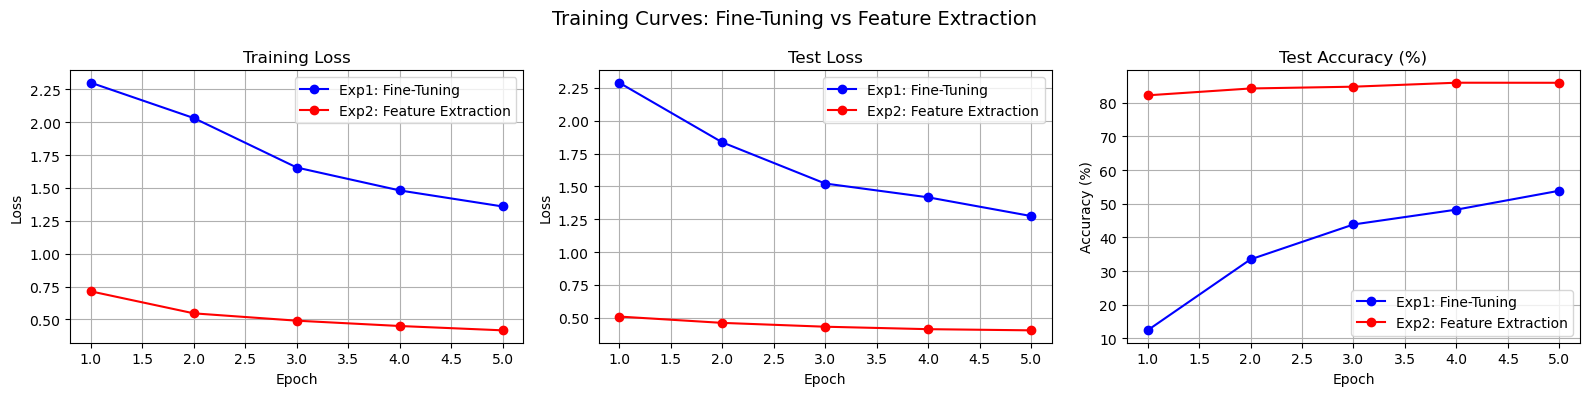

Chart saved to training_curves.png


In [21]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training Curves: Fine-Tuning vs Feature Extraction', fontsize=14)

# Training Loss
axes[0].plot(epochs, history_exp1['train_loss'], 'b-o', label='Exp1: Fine-Tuning')
axes[0].plot(epochs, history_exp2['train_loss'], 'r-o', label='Exp2: Feature Extraction')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Test Loss
axes[1].plot(epochs, history_exp1['test_loss'], 'b-o', label='Exp1: Fine-Tuning')
axes[1].plot(epochs, history_exp2['test_loss'], 'r-o', label='Exp2: Feature Extraction')
axes[1].set_title('Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Test Accuracy
axes[2].plot(epochs, history_exp1['test_acc'], 'b-o', label='Exp1: Fine-Tuning')
axes[2].plot(epochs, history_exp2['test_acc'], 'r-o', label='Exp2: Feature Extraction')
axes[2].set_title('Test Accuracy (%)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to training_curves.png')

---
## Explanation: Why is there a difference in performance?

### The Core Reason: Where the model starts

**Experiment 1 (Fine-Tuning / no pretrained weights):**  
Every single weight starts from a random number. The model has to learn *everything* from CIFAR-10's 50k training images — low-level features like edges, mid-level features like textures, and high-level features like object shapes — all in just 5 epochs. This is a hard problem. AlexNet has ~57 million parameters to tune, and 5 epochs with 50k images gives it only ~3.9 million weight updates. The model is still far from convergence.

**Experiment 2 (Feature Extraction / pretrained weights):**  
The convolutional layers already contain *years of learning* condensed from training on 1.2 million ImageNet images. These weights already know how to detect meaningful visual patterns. The model only needs to learn one small mapping: which of the 4096 features (output of the last FC layer before the classifier) are relevant for distinguishing CIFAR-10 classes. That's a much simpler problem — fewer parameters to tune, better starting point.

### An Analogy

Imagine teaching two students to recognize handwritten digits:
- **Student 1** has never seen images before. You must teach them what a line is, what a curve is, what shapes mean, and then what digits look like — all in one lesson.
- **Student 2** has spent years studying paintings, photographs, and diagrams. They already have rich visual understanding. You just need to show them a few examples of each digit.

Student 2 will almost always do better in the same amount of time.

### Domain Gap

There is one caveat: ImageNet images are typically large, high-resolution photographs of real-world objects. CIFAR-10 images are tiny 32×32 thumbnails. There is a **domain gap** — the pretrained features aren't a perfect match. This is why with more training, Experiment 1 might eventually *catch up* or even *surpass* Experiment 2 if it fully fine-tunes all layers. But in the short run, pretrained weights have a big advantage.

### Summary

| Factor | Exp 1 (Fine-Tuning) | Exp 2 (Feature Extraction) |
|--------|--------------------|--------------------------|
| Starting point | Random noise | Learned visual features |
| Parameters to train | ~57M | ~40K |
| Epochs to converge | Many | Few |
| Best with | Large dataset + many epochs | Small dataset or few epochs |
| Risk | Underfitting (with few epochs) | Domain mismatch |

**Transfer Learning is powerful precisely because good visual features generalize across many tasks.** This insight drives modern deep learning: models like ResNet, ViT, and CLIP are pretrained at scale and then adapted to specific downstream tasks.

---
## Common Questions & Answers

**Q1: What is the difference between Fine-Tuning and Feature Extraction?**

Fine-Tuning starts with random weights and trains all layers from scratch on CIFAR-10. Feature Extraction uses pretrained ImageNet weights and only trains the final classifier layer — the backbone is frozen.

---

**Q2: Why does Feature Extraction perform better with fewer epochs?**

The pretrained backbone already knows how to detect edges, textures, and shapes from training on 1.2M ImageNet images. It only needs to learn which features map to CIFAR-10 classes. Fine-Tuning starts from random noise and must learn everything from 50k images in a few epochs — a much harder problem.

---

**Q3: Why do we resize CIFAR-10 images from 32x32 to 224x224?**

AlexNet was designed for 224x224 inputs. Its first conv layer uses an 11x11 kernel with stride 4. Feeding 32x32 images directly would collapse the feature maps to nothing before reaching the FC layers.

---

**Q4: Why use ImageNet normalization statistics for CIFAR-10?**

In Experiment 2, the pretrained weights expect input normalized with ImageNet mean and std. Using different normalization would shift the input distribution and produce garbage activations through the frozen layers.

---

**Q5: Why do we freeze the backbone in Feature Extraction?**

The pretrained weights encode valuable visual knowledge. If we trained them on CIFAR-10's small dataset, we'd overwrite that knowledge with noise — a problem called **catastrophic forgetting**. Freezing preserves what the model already knows.

---

**Q6: What does `requires_grad=False` do?**

It tells PyTorch not to compute gradients for those parameters during backpropagation. No gradient means no weight update, so the layer stays frozen.

---

**Q7: Why pass only trainable parameters to the optimizer?**

```python
filter(lambda p: p.requires_grad, model.parameters())
```

If frozen parameters were passed to the optimizer, it would try to update them anyway. This filter ensures only the intended layers are updated.

---

**Q8: Will Fine-Tuning eventually outperform Feature Extraction?**

Yes — given enough epochs and data, fine-tuning all layers can exceed feature extraction because it adapts every layer to the target task. Feature Extraction has a **domain gap** disadvantage (ImageNet photos vs tiny CIFAR-10 thumbnails). But it wins in the short run.
